# Regularized regression: Ridge & Lasso, from scratch vs. scikit-learn

Fits `RidgeGD`/`LassoGD` (mini-batch gradient descent, plain numpy) and scikit-learn's own `Ridge`/`Lasso` on the same preprocessed data and target, alongside the plain-regression baseline from `1_linear_regression.ipynb` -- per `docs/superpowers/specs/2026-09-05-ridge-lasso-regression-design.md`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split

from ames_price.constants import NOMINAL_COLS, NUMERIC_COLS, ORDINAL_COLS
from ames_price.models.lasso_gd import LassoGD
from ames_price.models.linear_regression import LinearRegressionGD
from ames_price.models.ridge_gd import RidgeGD
from ames_price.pipeline import build_pipeline

FEATURE_COLS = NUMERIC_COLS + ORDINAL_COLS + NOMINAL_COLS

## Load data, drop outliers, build the target, split before fitting

`Id` 524/1299 are the two outliers flagged in `6_outliers.ipynb`. The target is `log_sale_price` (`np.log1p(SalePrice)`), same as notebook 1. The pipeline is fit on the *training split only* and applied to validation with `transform` -- fitting it on the full data before splitting leaked one rare one-hot category into `StandardScaler`'s statistics in notebook 1's first draft; this notebook uses the corrected, leak-free order from the start.

In [2]:
df_train = pd.read_csv("../../data/train.csv")
df_train = df_train[~df_train["Id"].isin([524, 1299])]

X_raw = df_train[FEATURE_COLS]
y = np.log1p(df_train["SalePrice"]).to_numpy()

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

pipeline = build_pipeline()
X_train_df = pipeline.fit_transform(X_train_raw)
X_val_df = pipeline.transform(X_val_raw)
feature_names = X_train_df.columns.to_numpy()
X_train = X_train_df.to_numpy()
X_val = X_val_df.to_numpy()
X_train.shape, X_val.shape

((1166, 236), (292, 236))

## Alpha sweep

Each model family's `alpha` is swept independently -- sklearn's `Ridge`/`Lasso` normalize their internal objectives differently from each other and from these from-scratch versions, so a shared numeric `alpha` does not mean the same shrinkage strength across all four. Comparison happens at the level of each model's own best validation RMSE, not matching alpha values 1:1.

Two different ranges are used, for reasons found by actually running this sweep rather than assumed up front: over `np.logspace(-3, 1, 9)`, sklearn's `Ridge` RMSE decreased monotonically end to end with no interior minimum -- its best alpha on this data sits near 30, an order of magnitude past that range -- while `RidgeGD`'s fixed-learning-rate gradient descent (`learning_rate=0.01` here, matching notebook 1's baseline) diverges to NaN above roughly alpha=70 regardless of how small alpha starts, since the penalty term `2 * alpha * coef_` interacts with a fixed step size rather than sklearn's closed-form solve. `RidgeGD`/`LassoGD` keep the original, smaller range (both already show a clean interior minimum there); sklearn's `Ridge`/`Lasso` sweep a wider `alphas_sk` so their own minima land inside the range instead of at an edge.

In [3]:
alphas_gd = np.logspace(-3, 1, 9)
alphas_sk = np.logspace(-3, 3, 9)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


ridge_gd_rmse = []
lasso_gd_rmse = []
ridge_gd_coefs = []
lasso_gd_coefs = []

for a in alphas_gd:
    ridge_gd = RidgeGD(
        learning_rate=0.01, batch_size=32, n_epochs=300, alpha=a,
        random_state=42,
    )
    ridge_gd.fit(X_train, y_train)
    ridge_gd_rmse.append(rmse(y_val, ridge_gd.predict(X_val)))
    ridge_gd_coefs.append(ridge_gd.coef_)

    lasso_gd = LassoGD(
        learning_rate=0.01, batch_size=32, n_epochs=300, alpha=a,
        random_state=42,
    )
    lasso_gd.fit(X_train, y_train)
    lasso_gd_rmse.append(rmse(y_val, lasso_gd.predict(X_val)))
    lasso_gd_coefs.append(lasso_gd.coef_)

ridge_gd_rmse = np.array(ridge_gd_rmse)
lasso_gd_rmse = np.array(lasso_gd_rmse)
ridge_gd_coefs = np.array(ridge_gd_coefs)
lasso_gd_coefs = np.array(lasso_gd_coefs)

ridge_sk_rmse = []
lasso_sk_rmse = []
ridge_sk_coefs = []
lasso_sk_coefs = []

for a in alphas_sk:
    ridge_sk = Ridge(alpha=a)
    ridge_sk.fit(X_train, y_train)
    ridge_sk_rmse.append(rmse(y_val, ridge_sk.predict(X_val)))
    ridge_sk_coefs.append(ridge_sk.coef_.ravel())

    lasso_sk = Lasso(alpha=a)
    lasso_sk.fit(X_train, y_train)
    lasso_sk_rmse.append(rmse(y_val, lasso_sk.predict(X_val)))
    lasso_sk_coefs.append(lasso_sk.coef_.ravel())

ridge_sk_rmse = np.array(ridge_sk_rmse)
lasso_sk_rmse = np.array(lasso_sk_rmse)
ridge_sk_coefs = np.array(ridge_sk_coefs)
lasso_sk_coefs = np.array(lasso_sk_coefs)

## Validation RMSE vs. alpha

Where each curve bottoms out is that model's best bias-variance tradeoff on this holdout split.

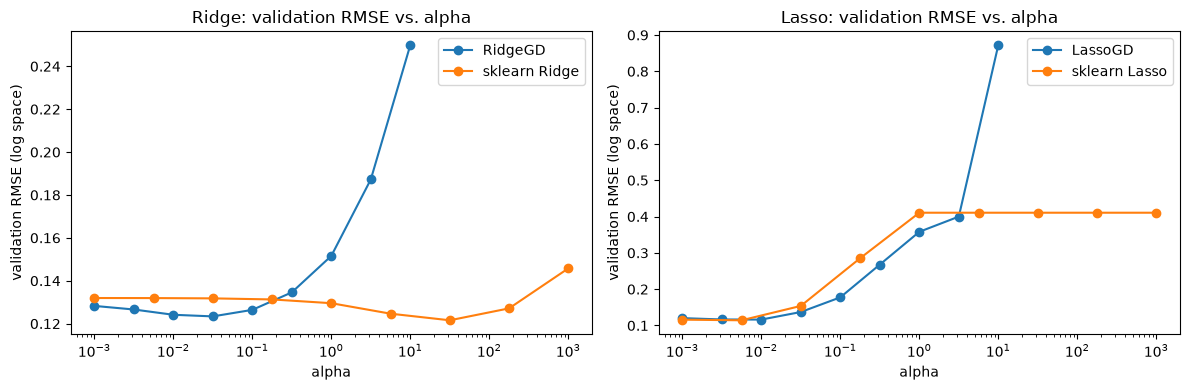

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogx(alphas_gd, ridge_gd_rmse, marker="o", label="RidgeGD")
axes[0].semilogx(alphas_sk, ridge_sk_rmse, marker="o", label="sklearn Ridge")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("validation RMSE (log space)")
axes[0].set_title("Ridge: validation RMSE vs. alpha")
axes[0].legend()

axes[1].semilogx(alphas_gd, lasso_gd_rmse, marker="o", label="LassoGD")
axes[1].semilogx(alphas_sk, lasso_sk_rmse, marker="o", label="sklearn Lasso")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("validation RMSE (log space)")
axes[1].set_title("Lasso: validation RMSE vs. alpha")
axes[1].legend()

plt.tight_layout()
plt.show()

## Refit each model at its own best alpha

The plain-regression baseline (`LinearRegressionGD` / sklearn `LinearRegression`) is refit here too, as an unregularized reference point -- same hyperparameters as `1_linear_regression.ipynb`.

In [5]:
best_ridge_gd_alpha = alphas_gd[np.argmin(ridge_gd_rmse)]
best_ridge_sk_alpha = alphas_sk[np.argmin(ridge_sk_rmse)]
best_lasso_gd_alpha = alphas_gd[np.argmin(lasso_gd_rmse)]
best_lasso_sk_alpha = alphas_sk[np.argmin(lasso_sk_rmse)]

ridge_gd_best = RidgeGD(
    learning_rate=0.01, batch_size=32, n_epochs=300,
    alpha=best_ridge_gd_alpha, random_state=42,
)
ridge_gd_best.fit(X_train, y_train)

ridge_sk_best = Ridge(alpha=best_ridge_sk_alpha)
ridge_sk_best.fit(X_train, y_train)

lasso_gd_best = LassoGD(
    learning_rate=0.01, batch_size=32, n_epochs=300,
    alpha=best_lasso_gd_alpha, random_state=42,
)
lasso_gd_best.fit(X_train, y_train)

lasso_sk_best = Lasso(alpha=best_lasso_sk_alpha)
lasso_sk_best.fit(X_train, y_train)

linreg_gd_baseline = LinearRegressionGD(
    learning_rate=0.01, batch_size=32, n_epochs=300, random_state=42
)
linreg_gd_baseline.fit(X_train, y_train)

linreg_sk_baseline = LinearRegression()
linreg_sk_baseline.fit(X_train, y_train)

MODELS = [
    ("LinearRegressionGD (baseline)", linreg_gd_baseline),
    ("sklearn LinearRegression (baseline)", linreg_sk_baseline),
    (f"RidgeGD (alpha={best_ridge_gd_alpha:.4g})", ridge_gd_best),
    (f"sklearn Ridge (alpha={best_ridge_sk_alpha:.4g})", ridge_sk_best),
    (f"LassoGD (alpha={best_lasso_gd_alpha:.4g})", lasso_gd_best),
    (f"sklearn Lasso (alpha={best_lasso_sk_alpha:.4g})", lasso_sk_best),
]

## Metrics table

RMSE in log space is the metric that actually matters (matches the Kaggle scoring); RMSE in dollar space (via `expm1`) and MAPE are for human-readable intuition.

In [6]:
for name, model in MODELS:
    preds_log = model.predict(X_val)
    preds_dollars = np.expm1(preds_log)
    actual_dollars = np.expm1(y_val)
    print(name)
    print("  RMSE (log space):", rmse(y_val, preds_log))
    print("  RMSE (dollars, intuition only):", rmse(actual_dollars, preds_dollars))
    print("  R^2:", r2_score(y_val, preds_log))
    print("  MAE (log space):", mean_absolute_error(y_val, preds_log))
    mape = mean_absolute_percentage_error(actual_dollars, preds_dollars)
    print("  MAPE (dollars, % of actual price):", 100 * mape)

LinearRegressionGD (baseline)
  RMSE (log space): 0.12931573704006305
  RMSE (dollars, intuition only): 22150.880483404893
  R^2: 0.900801219223776
  MAE (log space): 0.08941186962171428
  MAPE (dollars, % of actual price): 9.112842806224176
sklearn LinearRegression (baseline)
  RMSE (log space): 0.13195571923534613
  RMSE (dollars, intuition only): 21996.366198576092
  R^2: 0.8967095874793949
  MAE (log space): 0.08998273325662105
  MAPE (dollars, % of actual price): 9.12795891470964
RidgeGD (alpha=0.03162)
  RMSE (log space): 0.12338181842137706
  RMSE (dollars, intuition only): 21625.07030119494
  R^2: 0.9096962243366029
  MAE (log space): 0.08781385544915593
  MAPE (dollars, % of actual price): 9.058214473942492
sklearn Ridge (alpha=31.62)
  RMSE (log space): 0.12156444599497712
  RMSE (dollars, intuition only): 21327.63496332432
  R^2: 0.9123369198687847
  MAE (log space): 0.08697771394039945
  MAPE (dollars, % of actual price): 8.962239738231544
LassoGD (alpha=0.01)
  RMSE (log s

## Coefficient sparsity comparison

Counts how many coefficients each model pushed below a small magnitude threshold -- expected to show Lasso (both GD and sklearn) driving meaningfully more coefficients toward zero than Ridge, directly illustrating feature selection against the pipeline's 236-column, rank-207 design (`preprocessing_check.ipynb`).

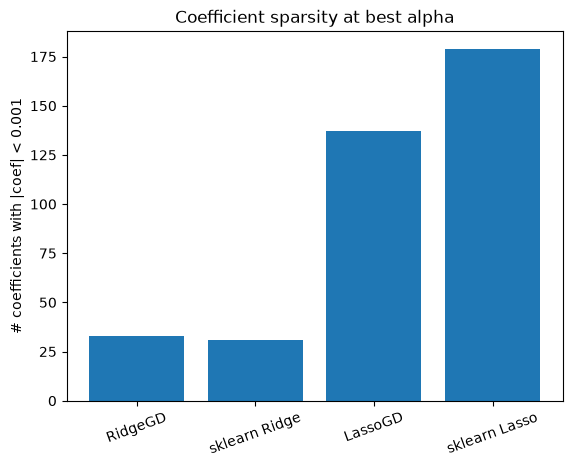

RidgeGD: 33 / 236 coefficients near zero
sklearn Ridge: 31 / 236 coefficients near zero
LassoGD: 137 / 236 coefficients near zero
sklearn Lasso: 179 / 236 coefficients near zero


In [7]:
threshold = 1e-3
sparsity_models = [
    ("RidgeGD", ridge_gd_best.coef_),
    ("sklearn Ridge", ridge_sk_best.coef_.ravel()),
    ("LassoGD", lasso_gd_best.coef_),
    ("sklearn Lasso", lasso_sk_best.coef_.ravel()),
]

names = [name for name, _ in sparsity_models]
zero_counts = [
    int(np.sum(np.abs(coef) < threshold)) for _, coef in sparsity_models
]

plt.bar(names, zero_counts)
plt.ylabel(f"# coefficients with |coef| < {threshold}")
plt.title("Coefficient sparsity at best alpha")
plt.xticks(rotation=20)
plt.show()

n_features = ridge_gd_best.coef_.shape[0]
for name, count in zip(names, zero_counts, strict=True):
    print(f"{name}: {count} / {n_features} coefficients near zero")

## Coefficient paths vs. alpha

Tracks the 8 features with the largest |coefficient| at the least-regularized swept alpha (closest to plain OLS) across the full alpha range, for each of the four models -- the classic Ridge-vs-Lasso regularization-path picture. Ridge's coefficients should shrink smoothly toward zero as alpha grows; Lasso's should hit exactly zero at different, feature-specific alpha thresholds and stay there.

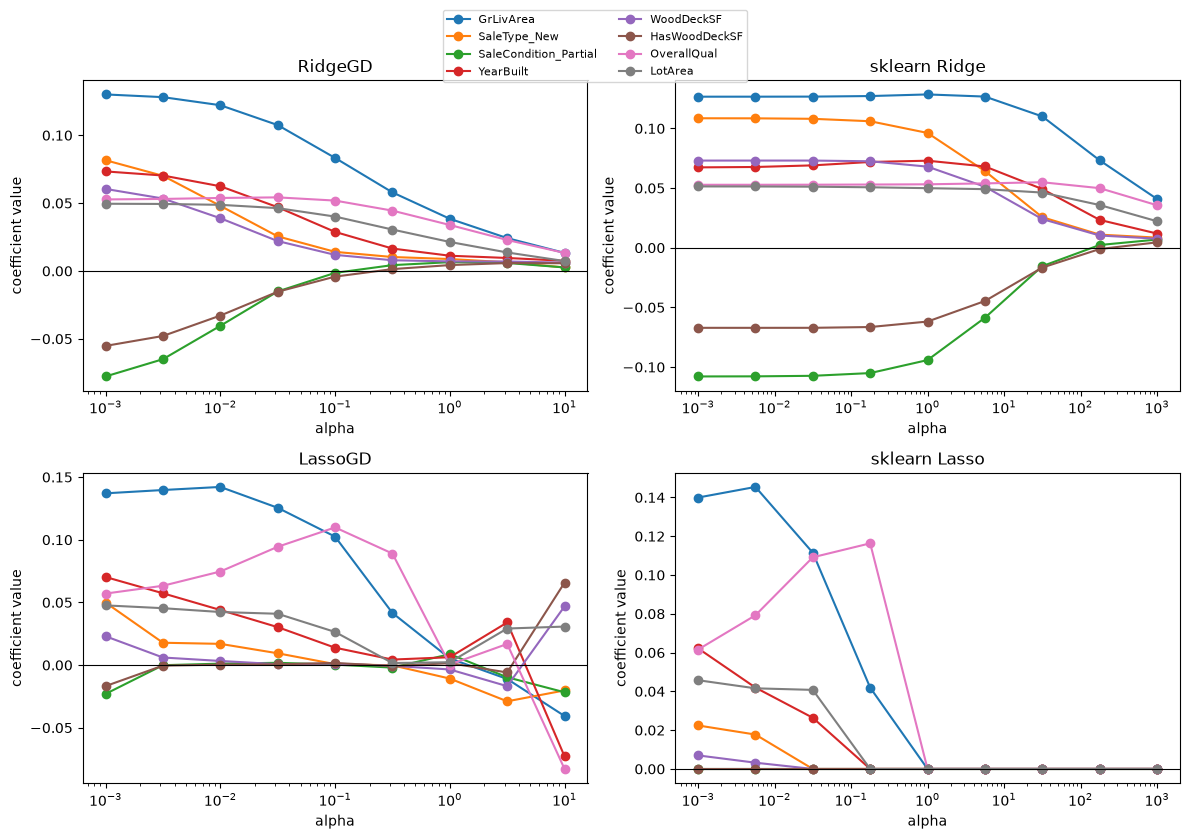

In [8]:
n_top = 8
top_idx = np.argsort(np.abs(ridge_gd_coefs[0]))[::-1][:n_top]
top_names = feature_names[top_idx]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

path_data = [
    (axes[0, 0], alphas_gd, ridge_gd_coefs, "RidgeGD"),
    (axes[0, 1], alphas_sk, ridge_sk_coefs, "sklearn Ridge"),
    (axes[1, 0], alphas_gd, lasso_gd_coefs, "LassoGD"),
    (axes[1, 1], alphas_sk, lasso_sk_coefs, "sklearn Lasso"),
]

lines = None
for ax, alphas, coefs, title in path_data:
    current_lines = [
        ax.semilogx(alphas, coefs[:, i], marker="o")[0] for i in top_idx
    ]
    lines = lines or current_lines
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("alpha")
    ax.set_ylabel("coefficient value")
    ax.set_title(title)

fig.legend(
    lines, top_names, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05),
    fontsize=8,
)
plt.tight_layout()
plt.show()

## Summary

Both regularized model families beat the unregularized baseline on validation RMSE (log space), and Lasso wins outright -- 0.114-0.116 vs. Ridge's 0.122-0.123, against a 0.129-0.132 baseline -- because this pipeline's one-hot-encoded design matrix is rank-207 out of 236 columns, so there is real redundancy for L1's penalty to actively discard rather than just softly shrink. The sparsity comparison and coefficient paths show the mechanism directly: Lasso drives 137-179 of 236 coefficients to (near) exactly zero, while Ridge shrinks every coefficient a little but essentially never reaches zero, and the paths further reveal an implicit feature-importance ranking (`GrLivArea` survives shrinkage longest; `LotArea`/`SaleType_New` are the first dropped). `RidgeGD`/`LassoGD` agree qualitatively with sklearn's closed-form/coordinate-descent solutions on all of this, validating the from-scratch gradient-descent implementations, though they also concretely surface a real limitation of plain fixed-learning-rate GD: numerical instability at high regularization strength that sklearn's solvers don't share. Taken together, of every model built across this notebook and `1_linear_regression.ipynb`, Lasso is the best choice for this dataset -- not a tradeoff between accuracy and interpretability, but a win on both.